In [33]:
import time
start = time.perf_counter()

print("Started")

import pandas as pd
import warnings
warnings.filterwarnings("ignore")

APPLE_DOC = "https://s2.q4cdn.com/470004039/files/doc_earnings/2024/q4/filing/10-Q4-2024-As-Filed.pdf"
TESLA_DOC = "https://ir.tesla.com/_flysystem/s3/sec/000162828024002390/tsla-20231231-gen.pdf"

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

apple_loader = PyPDFLoader(APPLE_DOC)

apple_doc = apple_loader.load()


def add_metadata(docs, document_name):
  for doc in docs:
    doc.metadata['document'] = document_name
    doc.metadata['page'] = doc.metadata.get('page', None)
  return docs

apple_doc = add_metadata(apple_doc, "Apple 10-K")

print("Extracted data from PDFs")

# Remove table of contents
apple_doc = [doc for doc in apple_doc if doc.metadata["page"] != 2]


import re
from langchain_core.documents import Document

# def split_by_item_headers(docs):
#     pattern = r"(\nItem\s+\d+[A-Z]?\.?.*?)\n"
#     structured_docs = []

#     for doc in docs:
#         text = doc.page_content

#         splits = re.split(pattern, text)

#         # re.split keeps headers separately, so recombine
#         for i in range(1, len(splits), 2):
#             header = splits[i].strip()
#             content = splits[i+1].strip() if i+1 < len(splits) else ""

#             structured_docs.append(
#                 Document(
#                     page_content=header + "\n" + content,
#                     metadata=doc.metadata
#                 )
#             )

#     return structured_docs

# apple_doc = split_by_item_headers(apple_doc)



# Chunking
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=150
)

chunked_docs_apple = text_splitter.split_documents(apple_doc)


# for doc in chunked_docs:
#    if (doc.metadata["page"] == 19) & ("Item 1B" in doc.page_content):
#       print(f"Page 20 content: {doc.page_content}")

print("Chunking completed")

# Embedding
from langchain_community.embeddings import HuggingFaceEmbeddings
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True}
)

print("Embedding completed")


# Put embeddings in vector db
from langchain_community.vectorstores import FAISS

vector_store_apple = FAISS.from_documents(
    chunked_docs_apple,
    embedding_model
)

retriever_apple = vector_store_apple.as_retriever(search_kwargs={"k":20})

Started
Extracted data from PDFs
Chunking completed
Using device: cpu


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1328.42it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding completed


In [34]:
query = "What was Apples total revenue for the fiscal year ended September 28, 2024?"

In [35]:
pages = []
for i in range(len(chunked_docs_apple)):
    pages.append(chunked_docs_apple[i].metadata["page"])
    # print(chunked_docs_apple[i].metadata["page"])
pages = set(pages)

In [37]:
len(pages)

120

In [39]:
for i in range(len(chunked_docs_apple)):
    if '391,035' in chunked_docs_apple[i].page_content:
        print(chunked_docs_apple[i].page_content)
        print("="*200)

Segment Operating Performance
The following table shows net sales by reportable segment for 2024, 2023 and 2022 (dollars in millions):
2024 Change 2023 Change 2022
Americas $ 167,045  3 % $ 162,560  (4) % $ 169,658 
Europe  101,328  7 %  94,294  (1) %  95,118 
Greater China  66,952  (8) %  72,559  (2) %  74,200 
Japan  25,052  3 %  24,257  (7) %  25,977 
Rest of Asia Pacific  30,658  4 %  29,615  1 %  29,375 
Total net sales $ 391,035  2 % $ 383,285  (3) % $ 394,328 
Americas
Americas net sales increased during 2024 compared to 2023 due primarily to higher net sales of Services.
Europe
Europe net sales increased during 2024 compared to 2023 due primarily to higher net sales of Services and iPhone.
Greater China
Products and Services Performance
The following table shows net sales by category for 2024, 2023 and 2022 (dollars in millions):
2024 Change 2023 Change 2022
iPhone $ 201,183  — % $ 200,583  (2) % $ 205,489 
Mac  29,984  2 %  29,357  (27) %  40,177 
iPad  26,694  (6) %  28,300  

In [40]:
rel_docs = retriever_apple.invoke(query)

In [41]:
print(len(rel_docs))

20


In [42]:
sim_check = vector_store_apple.similarity_search_with_score(query, k=20)

In [49]:
sim_check[0][0].page_content

'Apple Inc.\nCONSOLIDATED STATEMENTS OF OPERATIONS\n(In millions, except number of shares, which are reflected in thousands, and per-share amounts)\nYears ended\nSeptember 28,\n2024\nSeptember 30,\n2023\nSeptember 24,\n2022\nNet sales:\n   Products $ 294,866 $ 298,085 $ 316,199 \n   Services  96,169  85,200  78,129 \nTotal net sales  391,035  383,285  394,328 \nCost of sales:\n   Products  185,233  189,282  201,471 \n   Services  25,119  24,855  22,075 \nTotal cost of sales  210,352  214,137  223,546 \nGross margin  180,683  169,148  170,782 \nOperating expenses:\nResearch and development  31,370  29,915  26,251 \nSelling, general and administrative  26,097  24,932  25,094 \nTotal operating expenses  57,467  54,847  51,345 \nOperating income  123,216  114,301  119,437'

In [56]:
for i in range(len(sim_check)):
    if '391,035' in sim_check[i][0].page_content:
        print(sim_check[i][0].metadata["page"])

31
37


In [78]:
import time
start = time.perf_counter()

print("Started")

import pandas as pd
import warnings
warnings.filterwarnings("ignore")

APPLE_DOC = "https://s2.q4cdn.com/470004039/files/doc_earnings/2024/q4/filing/10-Q4-2024-As-Filed.pdf"
TESLA_DOC = "https://ir.tesla.com/_flysystem/s3/sec/000162828024002390/tsla-20231231-gen.pdf"

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

apple_loader = PyPDFLoader(APPLE_DOC)
tesla_loader = PyPDFLoader(TESLA_DOC)

apple_doc = apple_loader.load()
tesla_doc = tesla_loader.load()

def add_metadata(docs, document_name):
  for doc in docs:
    doc.metadata['document'] = document_name
    doc.metadata['page'] = doc.metadata.get('page', None)
  return docs

apple_doc = add_metadata(apple_doc, "Apple 10-K")
tesla_doc = add_metadata(tesla_doc, "Tesla 10-K")


print("Extracted data from PDFs")

# Remove table of contents
apple_doc = [doc for doc in apple_doc if doc.metadata["page"] != 2]
tesla_doc = [doc for doc in tesla_doc if doc.metadata["page"] != 2]
all_docs = apple_doc + tesla_doc

import re
from langchain_core.documents import Document




# Chunking
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=50
)

chunked_docs_apple = text_splitter.split_documents(apple_doc)
chunked_docs_tesla = text_splitter.split_documents(tesla_doc)
chunked_docs_combined = text_splitter.split_documents(all_docs)

# for doc in chunked_docs:
#    if (doc.metadata["page"] == 19) & ("Item 1B" in doc.page_content):
#       print(f"Page 20 content: {doc.page_content}")

import re
from langchain_core.documents import Document

def split_by_item_headers(docs):
    pattern = r"(\nItem\s+\d+[A-Z]?\.?.*?)\n"
    structured_docs = []

    for doc in docs:
        text = doc.page_content
        splits = re.split(pattern, text)

        # If no Item header found → keep full page
        if len(splits) <= 1:
            structured_docs.append(
                Document(
                    page_content=text.strip(),
                    metadata=doc.metadata.copy()
                )
            )
            continue

        # If headers found → recombine properly
        for i in range(1, len(splits), 2):
            header = splits[i].strip()
            content = splits[i+1].strip() if i+1 < len(splits) else ""

            structured_docs.append(
                Document(
                    page_content=header + "\n" + content,
                    metadata=doc.metadata.copy()
                )
            )

    return structured_docs

chunked_docs_apple = split_by_item_headers(chunked_docs_apple)
# tesla_doc = split_by_item_headers(tesla_doc)
# all_docs = split_by_item_headers(all_docs)

Started
Extracted data from PDFs


In [79]:
for i in range(len(chunked_docs_apple)):
    if "item 1b" in chunked_docs_apple[i].page_content.lower():
        print(chunked_docs_apple[i].metadata["page"]+1)
        print(chunked_docs_apple[i].page_content)
        print("="*50)

20
Item 1B. Unresolved Staff Comments
None.


In [66]:
pages = []
for i in range(len(chunked_docs_apple)):
    pages.append(chunked_docs_apple[i].metadata["page"])
    # print(chunked_docs_apple[i].metadata["page"])
pages = set(pages)

In [67]:
len(pages)

120

In [70]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

APPLE_DOC = "https://s2.q4cdn.com/470004039/files/doc_earnings/2024/q4/filing/10-Q4-2024-As-Filed.pdf"
TESLA_DOC = "https://ir.tesla.com/_flysystem/s3/sec/000162828024002390/tsla-20231231-gen.pdf"

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

apple_loader = PyPDFLoader(APPLE_DOC)
# tesla_loader = PyPDFLoader(TESLA_DOC)

apple_doc = apple_loader.load()
# tesla_doc = tesla_loader.load()

def add_metadata(docs, document_name):
  for doc in docs:
    doc.metadata['document'] = document_name
    doc.metadata['page'] = doc.metadata.get('page', None)
  return docs

apple_doc = add_metadata(apple_doc, "Apple 10-K")
# tesla_doc = add_metadata(tesla_doc, "Tesla 10-K")


print("Extracted data from PDFs")

# Remove table of contents
apple_doc = [doc for doc in apple_doc if doc.metadata["page"] != 2]
# tesla_doc = [doc for doc in tesla_doc if doc.metadata["page"] != 2]
# all_docs = apple_doc + tesla_doc

import re
from langchain_core.documents import Document




# Chunking
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500,
    chunk_overlap=100,
    # separators=["\nItem", "\n\n", "\n"]
)

chunked_docs_apple = text_splitter.split_documents(apple_doc)



import re
from langchain_core.documents import Document

def split_by_item_headers(docs):
    pattern = r"(\nItem\s+\d+[A-Z]?\.?.*?)\n"
    structured_docs = []

    for doc in docs:
        text = doc.page_content
        splits = re.split(pattern, text)

        # If no Item header found → keep full page
        if len(splits) <= 1:
            structured_docs.append(
                Document(
                    page_content=text.strip(),
                    metadata=doc.metadata.copy()
                )
            )
            continue

        # If headers found → recombine properly
        for i in range(1, len(splits), 2):
            header = splits[i].strip()
            content = splits[i+1].strip() if i+1 < len(splits) else ""

            structured_docs.append(
                Document(
                    page_content=header + "\n" + content,
                    metadata=doc.metadata.copy()
                )
            )

    return structured_docs

chunked_docs_apple = split_by_item_headers(chunked_docs_apple)

Extracted data from PDFs


In [71]:
character_count = []
for doc in chunked_docs_apple:
    character_count.append(len(doc.page_content))

(array([ 14.,  16.,  16.,  10.,   9.,  16.,  13.,   9.,  12., 233.]),
 array([  35. ,  181.3,  327.6,  473.9,  620.2,  766.5,  912.8, 1059.1,
        1205.4, 1351.7, 1498. ]),
 <BarContainer object of 10 artists>)

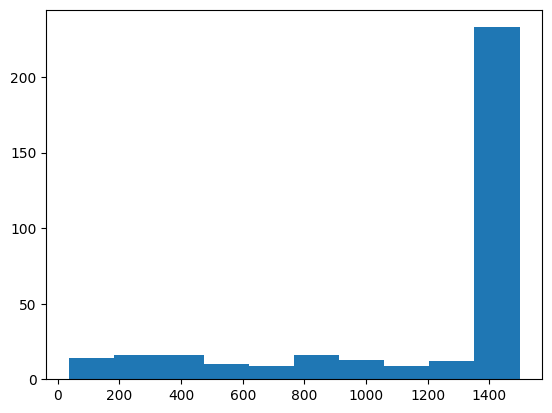

In [72]:
import matplotlib.pyplot as plt
plt.hist(character_count)

In [73]:
import numpy as np
np.percentile(character_count, 25)

np.float64(970.0)

In [67]:
for i in range(len(chunked_docs_apple)):
    if len(chunked_docs_apple[i].page_content) < np.percentile(character_count, 25):
        chunked_docs_apple[i].page_content = "Apple SEC 10-K report: " + chunked_docs_apple[i].page_content

print("Chunking completed")

# Embedding
from langchain_community.embeddings import HuggingFaceEmbeddings
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True}
)

print("Embedding completed")


# Put embeddings in vector db
from langchain_community.vectorstores import FAISS
from langchain_community.vectorstores.faiss import DistanceStrategy

vector_store_apple = FAISS.from_documents(
    chunked_docs_apple,
    embedding_model,
    # distance_strategy=DistanceStrategy.COSINE
)


retriever_apple = vector_store_apple.as_retriever(search_kwargs={"k":20})

Chunking completed
Using device: cpu
Embedding completed


In [24]:
# chunked_docs_apple[0].page_content

In [25]:
# chunked_docs_apple = [chunked_docs_apple for doc in chunked_docs_apple]

In [8]:
# for i in range(len(chunked_docs_apple)):
#     if "item 1b" in chunked_docs_apple[i].page_content.lower():
#         chunked_docs_apple[i].page_content = chunked_docs_apple[i].page_content*2

In [9]:
# for i in range(len(chunked_docs_apple)):
#     if "item 1b" in chunked_docs_apple[i].page_content.lower():
#         print(chunked_docs_apple[i])

In [10]:
# for i in range(len(chunked_docs_apple)):
#     if chunked_docs_apple[i].metadata["page"]==19:
#         print(chunked_docs_apple[i])

In [15]:
query = "What is the total amount of term debt (current + non-current) reported by Apple as of September 28, 2024?"

In [7]:
# rel_docs = retriever_apple.invoke(query)

In [68]:
sim_check = vector_store_apple.similarity_search_with_score(query, k=1000)

In [9]:
# sim_check

In [10]:
# for i in range(len(sim_check)):
#     if sim_check[i][0].metadata["page"] in [7,117,59,43,19]:
#         print(sim_check[i][0].metadata["page"], ":", sim_check[i][1])

In [19]:
# for i in range(5):
#     print(sim_check[i][0].metadata["page"], ":", sim_check[i][1], ":", sim_check[i][0].page_content)
#     print("="*100)

In [69]:
for i in range(len(sim_check)):
    if sim_check[i][0].metadata["page"] in [45]:
        print(sim_check[i][0].metadata["page"], ":", sim_check[i][1], ":", sim_check[i][0].page_content)
        print("="*100)

45 : 0.45739478 : Maturities
(calendar year)
2024 2023
Amount
(in millions)
Effective
Interest Rate
Amount
(in millions)
Effective
Interest Rate
2013 – 2023 debt issuances:
Fixed-rate 0.000% – 4.850% notes 2024 – 2062 $ 97,341 0.03% – 6.65% $ 106,572 0.03% – 6.72%
Total term debt principal  97,341  106,572 
Unamortized premium/(discount) and issuance 
costs, net  (321)  (356) 
Hedge accounting fair value adjustments  (358)  (1,113) 
Total term debt  96,662  105,103 
Less: Current portion of term debt  (10,912)  (9,822) 
Total non-current portion of term debt $ 85,750 $ 95,281 
To manage interest rate risk on certain of its U.S. dollar–denominated fixed-rate notes, the Company uses interest rate swaps to 
effectively convert the fixed interest rates to floating interest rates on a portion of these notes. Additionally, to manage foreign 
exchange rate risk on certain of its foreign currency–denominated notes, the Company uses cross-currency swaps to effectively 
convert these notes to U.

In [37]:
for i in range(len(sim_check)):
    if sim_check[i][0].metadata["page"] in [45]:
        print(sim_check[i][0].page_content)
        print("="*100)

Apple SEC 10-K report: exchange rate risk on certain of its foreign currency–denominated notes, the Company uses cross-currency swaps to effectively 
convert these notes to U.S. dollar–denominated notes.
The effective interest rates for the Notes include the interest on the Notes, amortization of the discount or premium and, if 
applicable, adjustments related to hedging.
The future principal payments for the Company’s Notes as of September 28, 2024, are as follows (in millions):
2025 $ 10,930 
2026  12,342 
2027  9,936 
2028  7,800 
2029  5,153 
Thereafter  51,180 
Total term debt principal $ 97,341 
Apple Inc. | 2024 Form 10-K | 43
Note 9 – Debt
Commercial Paper
The Company issues unsecured short-term promissory notes pursuant to a commercial paper program. The Company uses net 
proceeds from the commercial paper program for general corporate purposes, including dividends and share repurchases. As of 
September 28, 2024 and September 30, 2023, the Company had $10.0 billion and $6.0 b

In [42]:
for doc in apple_doc:
    if "96,662" in doc.page_content:
        print(doc.page_content)

Note 9 – Debt
Commercial Paper
The Company issues unsecured short-term promissory notes pursuant to a commercial paper program. The Company uses net 
proceeds from the commercial paper program for general corporate purposes, including dividends and share repurchases. As of 
September 28, 2024 and September 30, 2023, the Company had $10.0 billion and $6.0 billion of commercial paper outstanding, 
respectively, with maturities generally less than  nine months. The weighted-average interest rate of the Company’s commercial 
paper was 5.00% and 5.28% as of September 28, 2024  and September 30, 2023 , respectively. The following table provides a 
summary of cash flows associated with the issuance and maturities of commercial paper for 2024, 2023 and 2022 (in millions):
2024 2023 2022
Maturities 90 days or less:
Proceeds from/(Repayments of) commercial paper, net $ 3,960 $ (1,333) $ 5,264 
Maturities greater than 90 days:
Proceeds from commercial paper  —  —  5,948 
Repayments of commercial 

In [44]:
from docling.document_converter import DocumentConverter
from langchain_core.documents import Document

converter = DocumentConverter()
result = converter.convert(APPLE_DOC)

# export_to_markdown() generates the string with \n\n paragraph breaks
markdown_text = result.document.export_to_markdown()

lc_doc = Document(
    page_content=markdown_text,
    metadata=result.document.origin.model_dump() # Preserving metadata
)


[INFO] 2026-03-01 15:51:38,823 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-03-01 15:51:38,824 [RapidOCR] device_config.py:50: Using CPU device
[INFO] 2026-03-01 15:51:38,835 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\kensi\abb\abb_env\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.pth
[INFO] 2026-03-01 15:51:38,836 [RapidOCR] main.py:50: Using C:\Users\kensi\abb\abb_env\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.pth
[INFO] 2026-03-01 15:51:39,006 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-03-01 15:51:39,007 [RapidOCR] device_config.py:50: Using CPU device
[INFO] 2026-03-01 15:51:39,009 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\kensi\abb\abb_env\Lib\site-packages\rapidocr\models\ch_ptocr_mobile_v2.0_cls_infer.pth
[INFO] 2026-03-01 15:51:39,009 [RapidOCR] main.py:50: Using C:\Users\kensi\abb\abb_env\Lib\site-packages\rapidocr\models\ch_ptocr_mobile_v2.0_cls_infer.pth
[INFO] 2026-03-01 

In [48]:
from docling.document_converter import DocumentConverter
from langchain_core.documents import Document

converter = DocumentConverter()
result = converter.convert(APPLE_DOC)
docling_doc = result.document

langchain_docs = []

# Iterate through each page in the DoclingDocument
for page_kv in docling_doc.pages.items():
    page_no = page_kv[0]  # The page index (1-based)
    
    # Export only the content for this specific page
    # This preserves the \n\n structure for the page's blocks
    page_markdown = docling_doc.export_to_markdown(page_no=page_no)
    
    # Create the LangChain document with page-specific metadata
    lc_doc = Document(
        page_content=page_markdown,
        metadata={
            "page_number": page_no,
            # "title": docling_doc.origin.title,
            # "source": docling_doc.origin.filename
        }
    )
    langchain_docs.append(lc_doc)

# Result: A list of LangChain documents, one per page
print(f"Total pages extracted: {len(langchain_docs)}")
print(f"Page 1 Content Preview: {langchain_docs[0].page_content[:100]}")
print(f"Page 1 Metadata: {langchain_docs[0].metadata}")


[INFO] 2026-03-01 15:56:26,323 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-03-01 15:56:26,324 [RapidOCR] device_config.py:50: Using CPU device
[INFO] 2026-03-01 15:56:26,391 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\kensi\abb\abb_env\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.pth
[INFO] 2026-03-01 15:56:26,392 [RapidOCR] main.py:50: Using C:\Users\kensi\abb\abb_env\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.pth
[INFO] 2026-03-01 15:56:26,566 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-03-01 15:56:26,567 [RapidOCR] device_config.py:50: Using CPU device
[INFO] 2026-03-01 15:56:26,581 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\kensi\abb\abb_env\Lib\site-packages\rapidocr\models\ch_ptocr_mobile_v2.0_cls_infer.pth
[INFO] 2026-03-01 15:56:26,582 [RapidOCR] main.py:50: Using C:\Users\kensi\abb\abb_env\Lib\site-packages\rapidocr\models\ch_ptocr_mobile_v2.0_cls_infer.pth
[INFO] 2026-03-01 

Total pages extracted: 121
Page 1 Content Preview: (Mark One)

☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934


Page 1 Metadata: {'page_number': 1}


In [63]:
# for i in range(len(langchain_docs)):
#     print(langchain_docs[i].page_content)
#     print(langchain_docs[i].metadata.get("page_number"))
#     print("="*100)

In [64]:
import time
start = time.perf_counter()

print("Started")

import pandas as pd
import warnings
warnings.filterwarnings("ignore")

APPLE_DOC = "https://s2.q4cdn.com/470004039/files/doc_earnings/2024/q4/filing/10-Q4-2024-As-Filed.pdf"
TESLA_DOC = "https://ir.tesla.com/_flysystem/s3/sec/000162828024002390/tsla-20231231-gen.pdf"

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# apple_loader = PyPDFLoader(APPLE_DOC)
# tesla_loader = PyPDFLoader(TESLA_DOC)

# apple_doc = apple_loader.load()
# tesla_doc = tesla_loader.load()

import pickle
with open("langchain_with_docling_apple.pkl", "rb") as f:
    apple_doc = pickle.load(f)

with open("langchain_with_docling_tesla.pkl", "rb") as f:
    tesla_doc = pickle.load(f)

def add_metadata(docs, document_name):
  for doc in docs:
    doc.metadata['document'] = document_name
    doc.metadata['page'] = doc.metadata.get('page', None)
  return docs

apple_doc = add_metadata(apple_doc, "Apple 10-K")
tesla_doc = add_metadata(tesla_doc, "Tesla 10-K")


print("Extracted data from PDFs")

# Remove table of contents
apple_doc = [doc for doc in apple_doc if doc.metadata["page"] != 2]
tesla_doc = [doc for doc in tesla_doc if doc.metadata["page"] != 2]
# all_docs = apple_doc + tesla_doc

import re
from langchain_core.documents import Document

Started
Extracted data from PDFs


In [69]:
for i in range(len(apple_doc)):
    if apple_doc[i].metadata["page"] == 20:
        x = apple_doc[i].page_content

In [70]:
x

"The Company is also subject to the examination of its tax returns and other tax matters by the U.S. Internal Revenue Service and  other  tax  authorities  and  governmental  bodies.  The  Company  regularly  assesses  the  likelihood  of  an  adverse  outcome resulting from these examinations to determine the adequacy of its provision for taxes. There can be no assurance as to the outcome of these examinations. If the Company's effective tax rates were to increase, or if the ultimate determination of the Company's  taxes  owed  is  for  an  amount  in  excess  of  amounts  previously  accrued,  the  Company's  business,  results  of operations and financial condition could be materially adversely affected.\n\n## General Risks\n\n## The price of the Company's stock is subject to volatility.\n\nThe Company's stock has experienced substantial price volatility in the past and may continue to do so in the future. Additionally, the Company, the technology industry and the stock market as a 

In [ ]:
import re
from typing import List, Tuple
from langchain_core.documents import Document


def normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", text)


def build_full_text(docs: List[Document]) -> Tuple[str, List[int]]:
    full_text_parts = []
    page_offsets = []
    current_offset = 0

    for doc in docs:
        page_offsets.append(current_offset)

        page_text = doc.page_content
        full_text_parts.append(page_text)

        current_offset += len(page_text) + 1

    full_text = "\n".join(full_text_parts)

    return full_text, page_offsets

def extract_item_positions(full_text: str):
    pattern = r"(?im)^\s*(Item\s+\d+[A-Z]?)\s*\."

    item_positions = []

    for match in re.finditer(pattern, full_text):
        item_positions.append({
            "item": match.group(1).strip(),
            "position": match.start()
        })

    return item_positions

def assign_item_metadata(
    chunks: List[Document],
    full_text: str,
    item_positions: list
) -> List[Document]:

    normalized_full_text = normalize_text(full_text)

    for chunk in chunks:
        chunk_text = normalize_text(chunk.page_content)

        snippet = chunk_text[:300]
        start_index = normalized_full_text.find(snippet)

        if start_index == -1:
            continue

        current_item = None

        for item in item_positions:
            if item["position"] <= start_index:
                current_item = item["item"]
            else:
                break

        if current_item:
            chunk.metadata["item"] = current_item

    return chunks

In [101]:
apple_full_text, apple_offsets = build_full_text(apple_doc)

apple_item_positions = extract_item_positions(apple_full_text)

chunked_docs_apple = assign_item_metadata(
    chunked_docs_apple,
    apple_full_text,
    apple_item_positions
)

In [102]:
print(len(apple_item_positions))

23


In [103]:
for i in range(len(chunked_docs_apple)):
    if not chunked_docs_apple[i].metadata.get("item"):
        chunked_docs_apple[i].metadata["item"] = "NA"

In [105]:
for i in range(len(chunked_docs_apple)):
    print(chunked_docs_apple[i].metadata)

{'producer': 'Wdesk Fidelity Content Translations Version 010.004.252', 'creator': 'Workiva', 'creationdate': '2024-10-31T19:17:25+00:00', 'author': 'anonymous', 'moddate': '2024-10-31T14:07:33-07:00', 'title': '10-K 2024, 09.28.2024-2024-10-31-12-16', 'source': 'https://s2.q4cdn.com/470004039/files/doc_earnings/2024/q4/filing/10-Q4-2024-As-Filed.pdf', 'total_pages': 121, 'page': 0, 'page_label': '1', 'document': 'Apple 10-K', 'item': 'NA'}
{'producer': 'Wdesk Fidelity Content Translations Version 010.004.252', 'creator': 'Workiva', 'creationdate': '2024-10-31T19:17:25+00:00', 'author': 'anonymous', 'moddate': '2024-10-31T14:07:33-07:00', 'title': '10-K 2024, 09.28.2024-2024-10-31-12-16', 'source': 'https://s2.q4cdn.com/470004039/files/doc_earnings/2024/q4/filing/10-Q4-2024-As-Filed.pdf', 'total_pages': 121, 'page': 0, 'page_label': '1', 'document': 'Apple 10-K', 'item': 'NA'}
{'producer': 'Wdesk Fidelity Content Translations Version 010.004.252', 'creator': 'Workiva', 'creationdate': 

In [ ]:
sources =[]
for doc in chunked_docs_apple:
    sources.append((doc.metadata['document'], doc.metadata['item'], f"p. {int(doc.metadata['page'])+1}"))